In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Use your exact absolute Windows path
csv_path = r"C:\Users\91798\Documents\ANKIT SONI\Pressure-Quotient-IPL\data\processed\ipl_matches_data_fully_clean.csv"

# Load dataset
df_clean = pd.read_csv(csv_path)

# Normalize seasons
df_clean['season_clean'] = df_clean['season'].astype(str).str.split('/').str[0].astype(int)

# Filter wins
df_clean = df_clean[df_clean['result'] == 'win'].copy()
df_clean['toss_winner_won'] = (df_clean['toss_winner'] == df_clean['match_winner']).astype(int)

print(f"Success! Total valid matches loaded: {len(df_clean)}")


Success! Total valid matches loaded: 1187


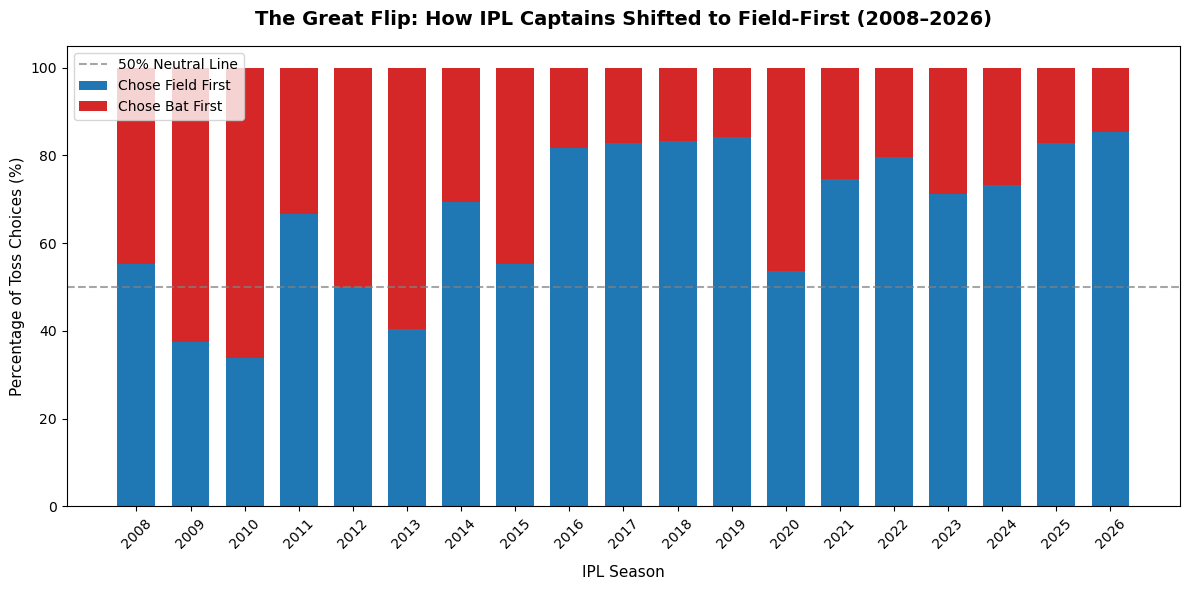

In [2]:

import os
import pandas as pd
import matplotlib.pyplot as plt

# Define an absolute path for your outputs folder
output_dir = r"C:\Users\91798\Documents\ANKIT SONI\Pressure-Quotient-IPL\outputs\charts"
os.makedirs(output_dir, exist_ok=True)

# Generate chart data
toss_counts = df_clean.groupby(['season_clean', 'toss_decision']).size().unstack(fill_value=0)
toss_pct = toss_counts.div(toss_counts.sum(axis=1), axis=0) * 100
toss_summary = toss_pct.reset_index()

plt.figure(figsize=(12, 6), dpi=100)
plt.bar(toss_summary['season_clean'], toss_summary['field'], label='Chose Field First', color='#1f77b4', width=0.7)
plt.bar(toss_summary['season_clean'], toss_summary['bat'], bottom=toss_summary['field'], label='Chose Bat First', color='#d62728', width=0.7)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Neutral Line')
plt.title('The Great Flip: How IPL Captains Shifted to Field-First (2008–2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('IPL Season', fontsize=11, labelpad=10)
plt.ylabel('Percentage of Toss Choices (%)', fontsize=11)
plt.xticks(toss_summary['season_clean'], rotation=45)
plt.ylim(0, 105)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# Save using the absolute path
plt.savefig(os.path.join(output_dir, 'toss_01_great_flip.png'), dpi=300)
plt.show()

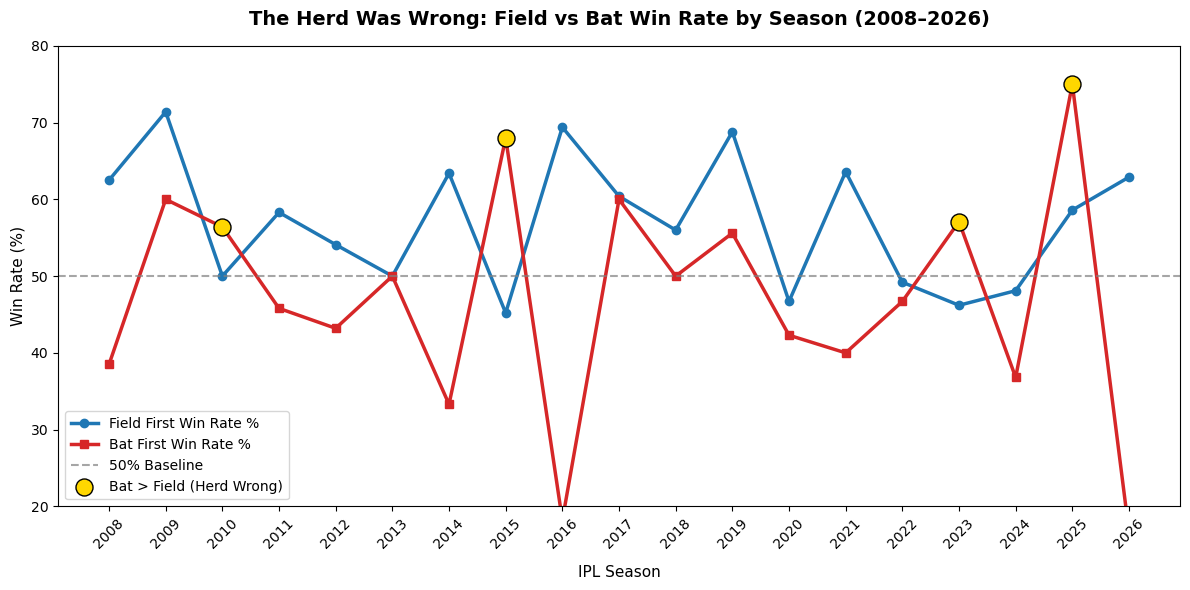

In [3]:

# --- CHART 2: Win Rate Paradox ---
wr_by_season = df_clean.groupby(['season_clean', 'toss_decision'])['toss_winner_won'].mean().unstack() * 100
wr_by_season = wr_by_season.round(1).reset_index()

plt.figure(figsize=(12, 6), dpi=100)
plt.plot(wr_by_season['season_clean'], wr_by_season['field'], marker='o', color='#1f77b4', linewidth=2.5, label='Field First Win Rate %')
plt.plot(wr_by_season['season_clean'], wr_by_season['bat'], marker='s', color='#d62728', linewidth=2.5, label='Bat First Win Rate %')
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Baseline')

bat_better_seasons = wr_by_season[wr_by_season['bat'] > wr_by_season['field']]
plt.scatter(bat_better_seasons['season_clean'], bat_better_seasons['bat'], color='gold', s=150, zorder=5, edgecolor='black', label='Bat > Field (Herd Wrong)')

plt.title('The Herd Was Wrong: Field vs Bat Win Rate by Season (2008–2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('IPL Season', fontsize=11, labelpad=10)
plt.ylabel('Win Rate (%)', fontsize=11)
plt.xticks(wr_by_season['season_clean'], rotation=45)
plt.ylim(20, 80)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'toss_02_win_rate_paradox.png'), dpi=300)
plt.show()

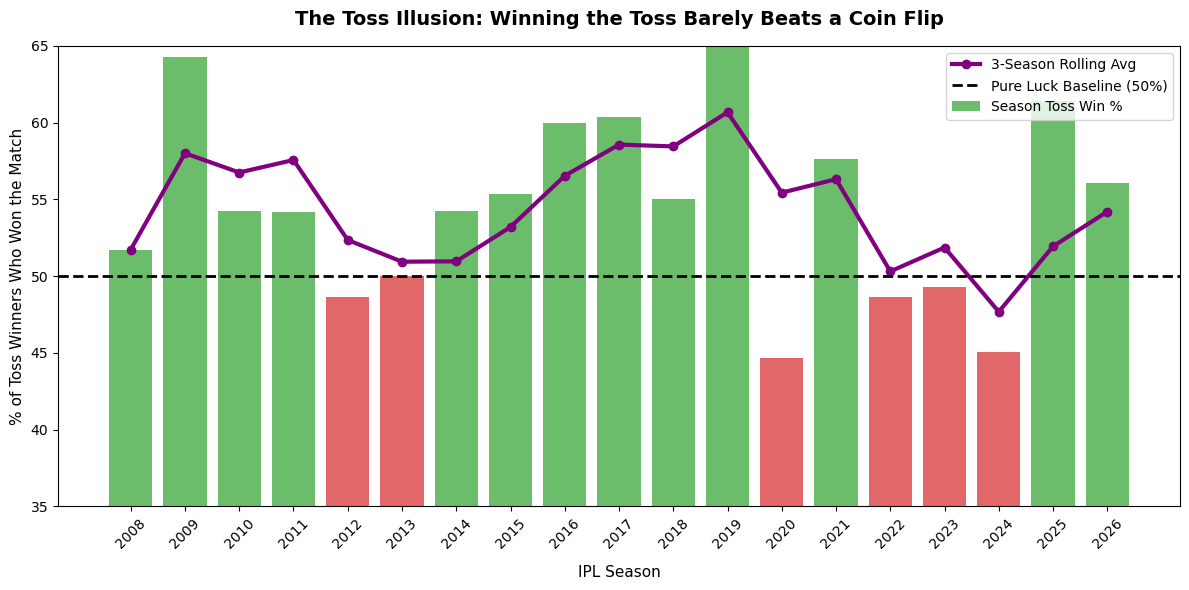

In [4]:
# --- CHART 3: The Toss Illusion ---
toss_adv_season = df_clean.groupby('season_clean')['toss_winner_won'].mean() * 100
toss_adv_season = toss_adv_season.reset_index()
toss_adv_season['rolling_3yr'] = toss_adv_season['toss_winner_won'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(12, 6), dpi=100)
colors = ['#2ca02c' if val > 50 else '#d62728' for val in toss_adv_season['toss_winner_won']]
plt.bar(toss_adv_season['season_clean'], toss_adv_season['toss_winner_won'], color=colors, alpha=0.7, label='Season Toss Win %')
plt.plot(toss_adv_season['season_clean'], toss_adv_season['rolling_3yr'], color='purple', linewidth=3, marker='o', label='3-Season Rolling Avg')
plt.axhline(50, color='black', linestyle='dashed', linewidth=2, label='Pure Luck Baseline (50%)')

plt.title('The Toss Illusion: Winning the Toss Barely Beats a Coin Flip', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('IPL Season', fontsize=11, labelpad=10)
plt.ylabel('% of Toss Winners Who Won the Match', fontsize=11)
plt.xticks(toss_adv_season['season_clean'], rotation=45)
plt.ylim(35, 65)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'toss_03_toss_illusion.png'), dpi=300)
plt.show()

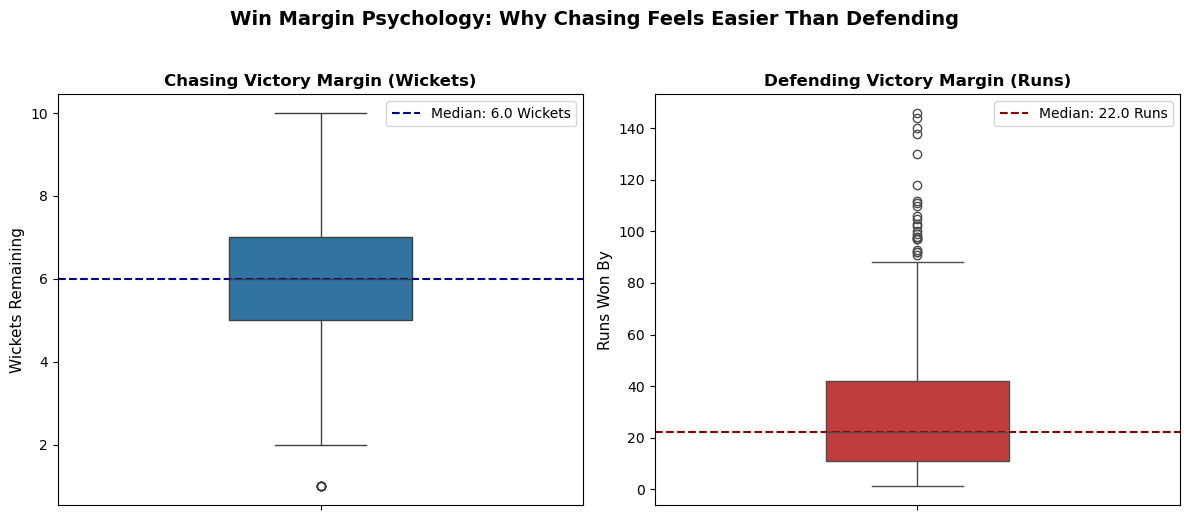

In [5]:
# --- CHART 4: Win Margin Psychology ---
win_wickets = df_clean[df_clean['win_by_wickets'] > 0]['win_by_wickets']
win_runs = df_clean[df_clean['win_by_runs'] > 0]['win_by_runs']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
sns.boxplot(y=win_wickets, ax=axes[0], color='#1f77b4', width=0.35)
axes[0].set_title('Chasing Victory Margin (Wickets)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Wickets Remaining', fontsize=11)
axes[0].axhline(win_wickets.median(), color='darkblue', linestyle='--', label=f'Median: {win_wickets.median():.1f} Wickets')
axes[0].legend(loc='upper right')

sns.boxplot(y=win_runs, ax=axes[1], color='#d62728', width=0.35)
axes[1].set_title('Defending Victory Margin (Runs)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Runs Won By', fontsize=11)
axes[1].axhline(win_runs.median(), color='darkred', linestyle='--', label=f'Median: {win_runs.median():.1f} Runs')
axes[1].legend(loc='upper right')

plt.suptitle('Win Margin Psychology: Why Chasing Feels Easier Than Defending', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'toss_04_win_margin_psychology.png'), dpi=300)
plt.show()


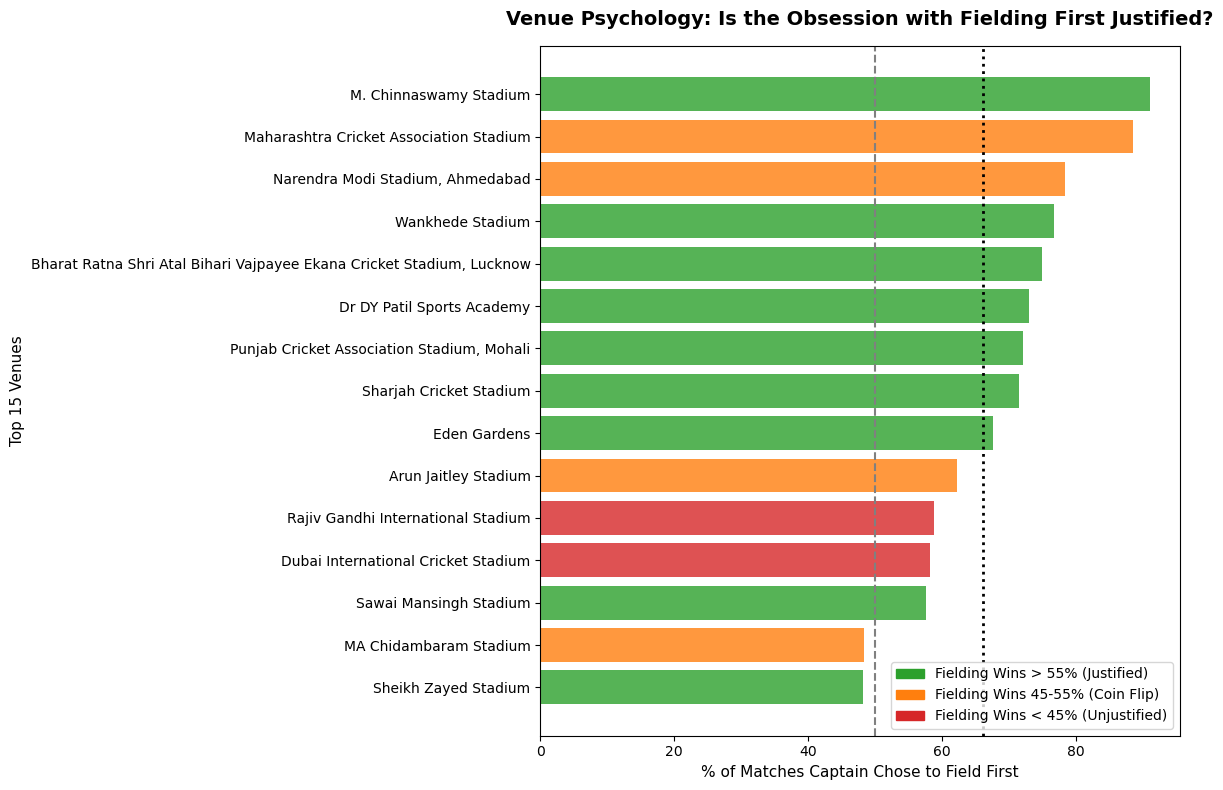

In [6]:

# --- CHART 5: Venue Psychology ---
top_15_venues = df_clean['venue'].value_counts().head(15).index
df_top_venues = df_clean[df_clean['venue'].isin(top_15_venues)].copy()

venue_stats = pd.DataFrame()
venue_stats['total_matches'] = df_top_venues.groupby('venue').size()
venue_stats['field_choices'] = df_top_venues[df_top_venues['toss_decision'] == 'field'].groupby('venue').size()
venue_stats['field_choice_pct'] = (venue_stats['field_choices'] / venue_stats['total_matches']) * 100

field_first_matches = df_top_venues[df_top_venues['toss_decision'] == 'field']
venue_stats['field_wins'] = field_first_matches.groupby('venue')['toss_winner_won'].sum()
venue_stats['field_win_pct'] = (venue_stats['field_wins'] / venue_stats['field_choices']) * 100
venue_stats = venue_stats.reset_index().sort_values('field_choice_pct', ascending=True)

def assign_color(win_pct):
    if win_pct > 55: return '#2ca02c'
    elif win_pct >= 45: return '#ff7f0e'
    else: return '#d62728'

venue_stats['color'] = venue_stats['field_win_pct'].apply(assign_color)

plt.figure(figsize=(12, 8), dpi=100)
plt.barh(venue_stats['venue'], venue_stats['field_choice_pct'], color=venue_stats['color'], alpha=0.8)
plt.axvline(50, color='gray', linestyle='--', label='50% Neutral Choice')
overall_avg = (df_clean['toss_decision'] == 'field').mean() * 100
plt.axvline(overall_avg, color='black', linestyle=':', linewidth=2, label=f'IPL Average Field Choice ({overall_avg:.0f}%)')
plt.title('Venue Psychology: Is the Obsession with Fielding First Justified?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% of Matches Captain Chose to Field First', fontsize=11)
plt.ylabel('Top 15 Venues', fontsize=11)

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#2ca02c', label='Fielding Wins > 55% (Justified)')
orange_patch = mpatches.Patch(color='#ff7f0e', label='Fielding Wins 45-55% (Coin Flip)')
red_patch = mpatches.Patch(color='#d62728', label='Fielding Wins < 45% (Unjustified)')
plt.legend(handles=[green_patch, orange_patch, red_patch], loc='lower right', frameon=True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'toss_05_venue_psychology.png'), dpi=300)
plt.show()

In [7]:
# --- CHART 6: Behavioral Framework ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
fig.suptitle('4 Cognitive Biases Behind the Field-First Orthodoxy in IPL', fontsize=18, fontweight='bold', y=0.96)

# Panel 1: Availability Heuristic
axes[0, 0].set_title('1. Availability Heuristic', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].text(0.5, 0.85, 'Dramatic chases stick in memory more\nthan dull bowling victories.', ha='center', fontsize=12)
close_runs = len(df_clean[(df_clean['win_by_runs'] > 0) & (df_clean['win_by_runs'] <= 10)])
close_wkts = len(df_clean[(df_clean['win_by_wickets'] > 0) & (df_clean['win_by_wickets'] <= 2)])
axes[0, 0].bar(['Close Defenses\n(<10 runs)', 'Close Chases\n(<2 wkts)'], [close_runs, close_wkts], color=['#d62728', '#1f77b4'], width=0.4)
axes[0, 0].set_ylim(0, max(close_runs, close_wkts) * 1.5)

# Panel 2: Regret Aversion
axes[0, 1].set_title('2. Regret Aversion', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].text(0.5, 0.5, 'Captains make decisions to minimize regret.\n\nDefending a small total concentrates blame\non the captain. Fielding first distributes\nblame to the bowlers.\n\nAverage chasing win feels dominant (6.1 wkts)\nAverage defending win feels narrow (29.3 runs)', 
                ha='center', va='center', fontsize=13, bbox=dict(facecolor='#f8f9fa', alpha=0.8, boxstyle='round,pad=1.5'))
axes[0, 1].axis('off')

# Panel 3: Herd Mentality
axes[1, 0].set_title('3. Herd Mentality', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].text(0.5, 0.9, 'Following the majority under uncertainty.', ha='center', fontsize=12)
axes[1, 0].plot(toss_summary['season_clean'], toss_summary['field'], color='#1f77b4', linewidth=3)
axes[1, 0].axhline(50, color='gray', linestyle='--', label='50% Line')
axes[1, 0].set_xticks([2008, 2017, 2026])
axes[1, 0].set_ylabel('Fielding Preference %')

# Panel 4: Loss Aversion
axes[1, 1].set_title('4. Loss Aversion', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].text(0.5, 0.5, '"Losing hurts twice as much as gaining feels good."\n- Kahneman & Tversky\n\nWhen setting a target, every run conceded\nfeels like a loss. Chasing converts an\nuncertain defense into a clear, psychologically\nsafe target.', 
                ha='center', va='center', fontsize=13, style='italic', bbox=dict(facecolor='#e6f2ff', alpha=0.8, boxstyle='round,pad=1.5'))
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig(os.path.join(output_dir, 'toss_06_behavioral_framework.png'), dpi=300)
plt.show()



C:\Users\91798\AppData\Local\Temp\ipykernel_2208\699337119.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.92])


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your cleaned dataset
df_clean = pd.read_csv(r"C:\Users\91798\Documents\ANKIT SONI\Pressure-Quotient-IPL\data\processed\ipl_matches_data_fully_clean.csv")

# 2. Check what season column is available
season_col = 'season_clean' if 'season_clean' in df_clean.columns else 'season'
print(f"Using season column: {season_col}")

# 3. Define path for your charts folder
output_dir = r"C:\Users\91798\Documents\ANKIT SONI\Pressure-Quotient-IPL\outputs\charts"
os.makedirs(output_dir, exist_ok=True)

# 4. Analyze Toss Psychology & Decision Impact
toss_counts = df_clean.groupby([season_col, 'toss_decision']).size().unstack(fill_value=0)
toss_pct = toss_counts.div(toss_counts.sum(axis=1), axis=0) * 100
toss_summary = toss_pct.reset_index()

print("Toss Psychology Analysis Ready!")

Using season column: season
Toss Psychology Analysis Ready!


In [2]:
import os
print("Current folder:", os.getcwd())
print("Files in this folder:", os.listdir('.'))

Current folder: C:\Users\91798
Files in this folder: [' CRICKET_ANALYTICS_SQL_LITE.ipynb', '-1.14-windows.xml', '.anaconda', '.antigravity-ide', '.aws', '.conda', '.continuum', '.gemini', '.git-for-windows-updater', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ssh', '.vscode', '.vscode-shared', '02_statistical_analysis.ipynb', '3D Objects', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'AVACADO_PROJECT.db', 'AVACADO_PROJECT.sqbpro', 'bluej', 'car_service.db', 'car_service.db-journal', 'class10', 'computer', 'Contacts', 'Cookies', 'cricstats.ipynb', 'delete', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'IPL_ANALYTICS.db', 'IPL_ANALYTICS.sqbpro', 'KAMA KTD.db', 'KAMA.db', 'KAMA.db-journal', 'LEVEL 8.ipynb', 'Links', 'Local Settings', 'manoj', 'MERGE.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{fcf71d62-f15e-11ef-a380-bb1dbccf28db}.TM.blf', 'NTUS